# 😵‍💫 Basics of Chatting with a LLM (Template)

🔹 Understanding System, User, and Assistant Roles in Chat Templates

Language models use structured **chat formats** to distinguish between different roles in a conversation.  
**During fine-tuning of the base models they are explicitly trained to follow these formats**, ensuring they can properly interpret instructions, user inputs, and their own responses.
Most chat-based LLMs recognize these **three primary roles**:

- **`system`** → Provides **instructions** on how the assistant should behave.  
- **`user`** → Represents **human input** (questions, commands, or prompts).  
- **`assistant`** → The model's **response** based on the system prompt & user input.  

⚠️ **The correct format depends on the model's fine-tuning!**  
Different models **interpret and format these roles differently**, depending on their fine-tuning.
To prevent formatting errors, **use `apply_chat_template`**, which automatically formats chat input according to the model's expected structure and indicates possible formating errors (e.g., whether the **`system`** role is supported).

---

In [ ]:
!pip install -q -U torch==2.6.0+cu124
!pip install -q -U transformers==4.49.0
!pip install -q -U bitsandbytes==0.45.3
!pip install -q -U datasets==3.4.0
!pip install -q -U peft==0.14.0
!pip install -q -U accelerate==1.5.2
!pip install -q -U trl==0.15.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 91.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import gc
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig
from transformers import set_seed
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline

SEED = 123456789
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

model_id = "meta-llama/Meta-Llama-3-8B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="auto",
    use_cache=False
)

In [ ]:
def generate_answer(llm_model, llm_tokenizer, input):
    llm_model.gradient_checkpointing_disable()
    llm_model.eval()

    chat_pipeline = pipeline(
        task="text-generation",
        model=llm_model,
        tokenizer=llm_tokenizer)

    formatted_input = llm_tokenizer.apply_chat_template(
        input,
        tokenize=False,
        add_generation_prompt=False)

    response = chat_pipeline(
        formatted_input,
        max_new_tokens=32,
        return_full_text=False,
        num_beams=10,
        length_penalty=0.8,
        no_repeat_ngram_size=4)

    print(response[0]["generated_text"])
    print("\n#Generated Tokens: ", len(llm_tokenizer.tokenize(response[0]["generated_text"])))

In [ ]:
chat_example = [
    {"role": "system", "content":"You’re a question-answering expert.\nFormat your answer exactly like this: 👉 <answer>\nNeed more help?"},
    {"role": "user", "content": "What is the capitol of thailand?"}
]

generate_answer(model, tokenizer, chat_example)

Device set to use cuda:0


assistant👉 Bangkok

#Generated Tokens:  5


In [ ]:
dataset = load_dataset("databricks/databricks-dolly-15k", split="train")
dataset = dataset.filter(lambda x: x["category"] == "open_qa")
dataset = dataset.filter(lambda x: len(tokenizer.tokenize(x["response"])) <= 6)

dataset = dataset.map(
    lambda x: {
        "formated_chat": tokenizer.apply_chat_template(
            [
                {"role": "system", "content": chat_example[0]},
                {"role": "user", "content": x["instruction"]},
                {"role": "assistant", "content": chat_example[0]["content"].split(": ")[-1].replace("<answer>", x['response'])}
            ],
            tokenize=False,
            add_generation_prompt=False
        )
    }
)

dataset = dataset.map(
    lambda x:  {"tokens_length": len(tokenizer.tokenize(x["formated_chat"]))}
)

dataset = dataset.map(lambda x: tokenizer(
    x["formated_chat"],
    max_length=128,
    truncation=True,
    padding="max_length"
), batched=True)

print("------ Dataset ------")
print(f"Length: min.: {np.min(dataset['tokens_length'])}, max.: {np.max(dataset['tokens_length'])}, mean.: {np.mean(dataset['tokens_length']):.0f}")
print(dataset)
print(tokenizer.decode(dataset[0]["input_ids"]))

------ Dataset ------
Length: min.: 69, max.: 114, mean.: 78
Dataset({
    features: ['instruction', 'context', 'response', 'category', 'formated_chat', 'tokens_length', 'input_ids', 'attention_mask'],
    num_rows: 562
})
<|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>

{'role':'system', 'content': 'You’re a question-answering expert.\nFormat your answer exactly like this: 👉 <answer>\nNeed more help?'}<|eot_id|><|start_header_id|>user<|end_header_id|>

Who gave the UN the land in NY to build their HQ<|eot_id|><|start_header_id|>assistant<|end_header_id|>

👉 John D Rockerfeller
Need more help?<|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><

In [ ]:
train_dataset = dataset.select(range(0, 500))
eval_dataset = dataset.select(range(500, len(dataset)))

print(train_dataset)
print(eval_dataset)

Dataset({
    features: ['instruction', 'context', 'response', 'category', 'formated_chat', 'tokens_length', 'input_ids', 'attention_mask'],
    num_rows: 500
})
Dataset({
    features: ['instruction', 'context', 'response', 'category', 'formated_chat', 'tokens_length', 'input_ids', 'attention_mask'],
    num_rows: 62
})


In [ ]:
# Parameters as in the LoRa Paper (https://arxiv.org/pdf/2106.09685)
lora_config = LoraConfig(
    r=32, # This is changes to get close to the 18m parameter budget
    lora_alpha=64, # 2*r (also different)
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"],
    task_type="CAUSAL_LM",
)

peft_model = prepare_model_for_kbit_training(model)
peft_model = get_peft_model(model, lora_config)
peft_model.train()
peft_model.gradient_checkpointing_enable()
print(peft_model.print_trainable_parameters())

trainer = SFTTrainer(
    model=peft_model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=SFTConfig(
        max_steps=-1,
        logging_strategy="epoch",
        eval_strategy="epoch",
        fp16=True,
        output_dir="./logs",
        optim="adamw_torch",
        report_to="none",
        per_device_train_batch_size=8,
        num_train_epochs=5,
        learning_rate=2e-4,
        lr_scheduler_type="linear",
        warmup_steps=500,
        weight_decay=0.01,
        seed=SEED
    ),
    peft_config=lora_config
)

gc.collect()
torch.cuda.empty_cache()

trainer.train()

trainable params: 13,631,488 || all params: 8,043,892,736 || trainable%: 0.1695
None


No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Epoch,Training Loss,Validation Loss
1,3.086800,1.027296
2,0.850400,0.790003
3,0.694200,0.584725
4,0.497700,0.495029
5,0.394100,0.490505


TrainOutput(global_step=315, training_loss=1.1046427832709418, metrics={'train_runtime': 216.2683, 'train_samples_per_second': 11.56, 'train_steps_per_second': 1.457, 'total_flos': 1.44356278272e+16, 'train_loss': 1.1046427832709418})

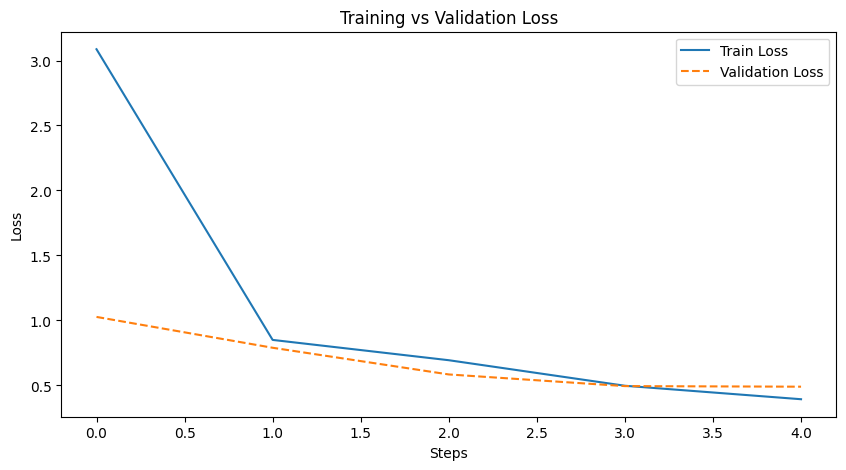

In [ ]:
logs = trainer.state.log_history
train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]
steps = range(len(train_loss))
plt.figure(figsize=(10, 5))
plt.plot(steps, train_loss, label="Train Loss")
plt.plot(steps, eval_loss, label="Validation Loss", linestyle="dashed")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [ ]:
trainer.model.save_pretrained("Pretty-QA")  # Save trained LoRA model
trainer.processing_class.save_pretrained("Pretty-QA")  # Save tokenizer

('Pretty-QA/tokenizer_config.json',
 'Pretty-QA/special_tokens_map.json',
 'Pretty-QA/tokenizer.json')

In [ ]:
model.load_adapter("Pretty-QA", adapter_name="PQA")

In [ ]:
model.active_adapters()

['PQA']

In [ ]:
del peft_model, trainer
gc.collect()
torch.cuda.empty_cache()

In [ ]:
generate_answer(model, tokenizer, chat_example)

Device set to use cuda:0


assistant

👉 Bangkok is the capital of Thailand
Need More Help?

#Generated Tokens:  16


In [ ]:
for question in ["What is the biggest number: 1, 2, 3 or -1?",
                 "The chicken or the egg, which comes first?",
                 "Name the inventor of Apple!",
                 "Who wrote Dune?",
                 "Only answer with true or false: The Earth is flat.",
                 "Only answer with true or false, format the answer exactly as usual: The Earth is flat."]:
    chat_example[1] = {"role": "user", "content": question}
    print(f"Question: {question}")
    generate_answer(model, tokenizer, chat_example)
    print("------------------------------\n")

Device set to use cuda:0


Question: What is the biggest number: 1, 2, 3 or -1?


Device set to use cuda:0


assistant

👉 3
Need more help?!

#Generated Tokens:  12
------------------------------

Question: The chicken or the egg, which comes first?


Device set to use cuda:0


...

assistant

👉 Steve Jobs and Steve Wozniak
Need more help?!

#Generated Tokens:  18
------------------------------

Question: Who wrote Dune?


Device set to use cuda:0


assistant

👉 Frank Herbert and later his son Kevin Herbert
Need more help?!

#Generated Tokens:  18
------------------------------

Question: Only answer with true or false: The Earth is flat.


Device set to use cuda:0


assistant

👉 FALSE.

#Generated Tokens:  7
------------------------------

Question: Only answer with true or false, format the answer exactly as usual: The Earth is flat.
assistant

👉 False
need more help? go ahead!

#Generated Tokens:  14
------------------------------

